In [1]:
import pandas as pd
import sqlite3
import numpy as np
import time
import os
import requests
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle, Rectangle, Arc
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from nba_api.stats.static import players
from nba_api.stats.endpoints import commonplayerinfo
from nba_api.stats.endpoints import shotchartdetail
from nba_api.stats.static import teams


In [2]:
conn = sqlite3.connect('nba_centers_info.db')

# Drop the ShotLocs table entirely as it does not include game date.
conn.execute("DROP TABLE IF EXISTS ShotLocs")
conn.commit()

In [3]:

def get_shot_loc(start,end):
    desired_seasons = [f"{year}-{str(year+1)[2:]}" for year in range(start, end + 1)]

    seasons = desired_seasons

    shot_loc = []

    for season in seasons: 
        print(f"Fetching player shot locations for {season}...")

        try:
            info = shotchartdetail.ShotChartDetail(
                team_id = 0,
                player_id = 0,
                season_nullable = season, 
                context_measure_simple = 'FGA', 
                season_type_all_star = 'Regular Season')
            df = info.get_data_frames()[0]

            desired_info = df[['PLAYER_ID', 'PLAYER_NAME', 'TEAM_NAME', 'GAME_DATE','PERIOD', 
                               'EVENT_TYPE', 'SHOT_TYPE', 'SHOT_DISTANCE', 'LOC_X', 'LOC_Y']]

            shot_loc.append(desired_info)

            time.sleep(1)

        except Exception as e:
            print(f"Error {e}")

    if shot_loc:
        final_df = pd.concat(shot_loc, ignore_index=True)
        
        # Add to the 'ShotLocations' table
        final_df.to_sql('ShotLocs', conn, if_exists='append', index=False)
        print(final_df)


In [4]:
get_shot_loc(2013, 2024)

Fetching player shot locations for 2013-14...
Fetching player shot locations for 2014-15...
Fetching player shot locations for 2015-16...
Fetching player shot locations for 2016-17...
Fetching player shot locations for 2017-18...
Fetching player shot locations for 2018-19...
Fetching player shot locations for 2019-20...
Fetching player shot locations for 2020-21...
Fetching player shot locations for 2021-22...
Fetching player shot locations for 2022-23...
Fetching player shot locations for 2023-24...
Fetching player shot locations for 2024-25...
         PLAYER_ID       PLAYER_NAME              TEAM_NAME GAME_DATE  PERIOD  \
0             2561        David West         Indiana Pacers  20131029       1   
1           202331       Paul George         Indiana Pacers  20131029       1   
2           201167     Arron Afflalo          Orlando Magic  20131029       1   
3             2561        David West         Indiana Pacers  20131029       1   
4           202362  Lance Stephenson       

In [5]:
shot_loc_df = pd.read_sql("SELECT * FROM ShotLocs", conn)
shot_loc_df

,PLAYER_ID,PLAYER_NAME,TEAM_NAME,GAME_DATE,PERIOD,EVENT_TYPE,SHOT_TYPE,SHOT_DISTANCE,LOC_X,LOC_Y
0,2561,David West,Indiana Pacers,20131029,1,Missed Shot,2PT Field Goal,5.0,-38.0,45.0
1,202331,Paul George,Indiana Pacers,20131029,1,Made Shot,2PT Field Goal,19.0,105.0,164.0
2,201167,Arron Afflalo,Orlando Magic,20131029,1,Missed Shot,3PT Field Goal,27.0,51.0,266.0
3,2561,David West,Indiana Pacers,20131029,1,Missed Shot,2PT Field Goal,2.0,28.0,-5.0
4,202362,Lance Stephenson,Indiana Pacers,20131029,1,Made Shot,3PT Field Goal,26.0,15.0,260.0
...,...,...,...,...,...,...,...,...,...,...
2510333,1630578,Alperen Sengun,Houston Rockets,20241214,4,Missed Shot,3PT Field Goal,25.0,-29.0,257.0
2510334,1627832,Fred VanVleet,Houston Rockets,20241214,4,Missed Shot,3PT Field Goal,22.0,-228.0,-17.0
2510335,1629652,Luguentz Dort,Oklahoma City Thunder,20241214,4,Made Shot,3PT Field Goal,24.0,186.0,167.0
2510336,1630224,Jalen Green,Houston Rockets,20241214,4,Made Shot,2PT Field Goal,2.0,12.0,16.0


In [6]:
centers_df = pd.read_sql("SELECT * FROM Centers", conn)
centers_df

,PERSON_ID,DISPLAY_FIRST_LAST,POSITION,HEIGHT,TEAM_NAME
0,203500,Steven Adams,Center,6-11,Rockets
1,1628386,Jarrett Allen,Center,6-9,Cavaliers
2,1629028,Deandre Ayton,Center,7-0,Lakers
3,202687,Bismack Biyombo,Center,6-8,Spurs
4,203991,Clint Capela,Center,6-10,Rockets
...,...,...,...,...,...
696,1917,Wang Zhi-zhi,Center,7-1,
697,678,George Zidek,Center,7-0,
698,1627757,Stephen Zimmerman,Center,7-0,Magic
699,1627790,Ante Zizic,Center,6-10,Cavaliers


In [11]:
finaldata = pd.read_sql('''SELECT 
            sl.PLAYER_NAME,
            c.POSITION,
            sl.GAME_DATE,
            sl.TEAM_NAME,
            sl.EVENT_TYPE,
            sl.SHOT_TYPE,
            sl.LOC_X,
            sl.LOC_Y
            FROM ShotLocs as sl
            INNER JOIN Centers as c
            ON sl.PLAYER_ID = c.PERSON_ID''', conn)
finaldata

,PLAYER_NAME,POSITION,GAME_DATE,TEAM_NAME,EVENT_TYPE,SHOT_TYPE,LOC_X,LOC_Y
0,Roy Hibbert,Center,20131029,Indiana Pacers,Missed Shot,2PT Field Goal,13.0,9.0
1,Roy Hibbert,Center,20131029,Indiana Pacers,Made Shot,2PT Field Goal,4.0,0.0
2,Roy Hibbert,Center,20131029,Indiana Pacers,Missed Shot,2PT Field Goal,-97.0,15.0
3,Nikola Vučević,Center,20131029,Orlando Magic,Made Shot,2PT Field Goal,-48.0,7.0
4,Nikola Vučević,Center,20131029,Orlando Magic,Missed Shot,2PT Field Goal,12.0,0.0
...,...,...,...,...,...,...,...,...
201033,Alperen Sengun,Center,20241214,Houston Rockets,Made Shot,2PT Field Goal,-17.0,41.0
201034,Alperen Sengun,Center,20241214,Houston Rockets,Made Shot,3PT Field Goal,146.0,220.0
201035,Alperen Sengun,Center,20241214,Houston Rockets,Made Shot,2PT Field Goal,64.0,101.0
201036,Alperen Sengun,Center,20241214,Houston Rockets,Made Shot,2PT Field Goal,10.0,0.0


In [12]:
print(finaldata.dtypes)

PLAYER_NAME     object
POSITION        object
GAME_DATE       object
TEAM_NAME       object
EVENT_TYPE      object
SHOT_TYPE       object
LOC_X          float64
LOC_Y          float64
dtype: object


In [13]:
finaldata['YEAR'] = finaldata['GAME_DATE'].str[:-4] 

In [14]:
finaldata

,PLAYER_NAME,POSITION,GAME_DATE,TEAM_NAME,EVENT_TYPE,SHOT_TYPE,LOC_X,LOC_Y,YEAR
0,Roy Hibbert,Center,20131029,Indiana Pacers,Missed Shot,2PT Field Goal,13.0,9.0,2013
1,Roy Hibbert,Center,20131029,Indiana Pacers,Made Shot,2PT Field Goal,4.0,0.0,2013
2,Roy Hibbert,Center,20131029,Indiana Pacers,Missed Shot,2PT Field Goal,-97.0,15.0,2013
3,Nikola Vučević,Center,20131029,Orlando Magic,Made Shot,2PT Field Goal,-48.0,7.0,2013
4,Nikola Vučević,Center,20131029,Orlando Magic,Missed Shot,2PT Field Goal,12.0,0.0,2013
...,...,...,...,...,...,...,...,...,...
201033,Alperen Sengun,Center,20241214,Houston Rockets,Made Shot,2PT Field Goal,-17.0,41.0,2024
201034,Alperen Sengun,Center,20241214,Houston Rockets,Made Shot,3PT Field Goal,146.0,220.0,2024
201035,Alperen Sengun,Center,20241214,Houston Rockets,Made Shot,2PT Field Goal,64.0,101.0,2024
201036,Alperen Sengun,Center,20241214,Houston Rockets,Made Shot,2PT Field Goal,10.0,0.0,2024


In [27]:
#We are now done with the database, so we can close it. 
conn.close()

In [15]:
def draw_court(ax=None, color='black', lw=1.5):
    if ax is None:
        ax = plt.gca()

    # Hoop
    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)
    # Backboard
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)
    # Paint
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False)
    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False)
    # Free throw arcs
    top_ft = Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color)
    bottom_ft = Arc((0, 142.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color, linestyle='dashed')
    # Restricted zone
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color)
    # Three point line
    corner_three_l = Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color)
    corner_three_r = Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color)
    # Center court
    center_outer = Arc((0, 422.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color)
    # Half court line
    outer_lines = Rectangle((-250, -47.5), 500, 470, linewidth=lw, color=color, fill=False)

    court_elements = [hoop, backboard, outer_box, inner_box, top_ft, bottom_ft,
                      restricted, corner_three_l, corner_three_r, three_arc,
                      center_outer, outer_lines]

    for element in court_elements:
        ax.add_patch(element)

    ax.set_xlim(-250, 250)
    ax.set_ylim(-47.5, 422.5)
    ax.set_aspect('equal')
    return ax


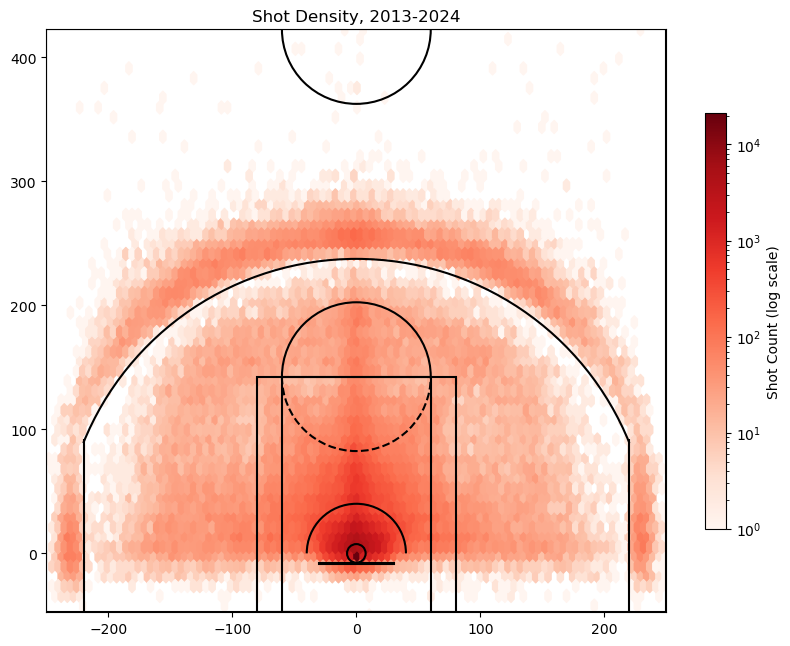

In [16]:
fig, ax = plt.subplots(figsize=(10, 9))

ax.hexbin(finaldata.LOC_X, finaldata.LOC_Y, gridsize=100, cmap='Reds', norm=LogNorm(), zorder=1)
draw_court(ax=ax, color='black', lw=1.5)

ax.set_title("Shot Density, 2013-2024")
ax.set_facecolor('white')
fig.colorbar(ax.collections[0], ax=ax, label='Shot Count (log scale)', shrink = 0.6)
plt.show()

In [17]:
years = sorted(finaldata['YEAR'].unique())

fig, ax = plt.subplots(figsize=(10, 9))

# Colorbar with a generic normalized scale
dummy = ax.hexbin([], [], gridsize=40, cmap='Reds', norm=LogNorm(vmin=1, vmax=1000))
fig.colorbar(dummy, ax=ax, label='Relative Shot Density (log scale)', shrink=0.6, aspect=15)

def animate(i):
    ax.clear()
    year = years[i]
    year_data = finaldata[finaldata['YEAR'] == year]
    
    # Let each year scale to its own data range
    ax.hexbin(year_data.LOC_X, year_data.LOC_Y, gridsize=120,
              cmap='Reds', norm=LogNorm(), zorder=1)
    draw_court(ax=ax, color='black', lw=1.5)
    ax.set_title(f"Center Shot Density — {year}", fontsize=14)
    ax.set_facecolor('white')
    ax.set_xlim(-250, 250)
    ax.set_ylim(-47.5, 422.5)

anim = FuncAnimation(fig, animate, frames=len(years), interval=1000, repeat=True)
anim.save('shot_density_by_year.gif', writer=PillowWriter(fps=1))
plt.close()

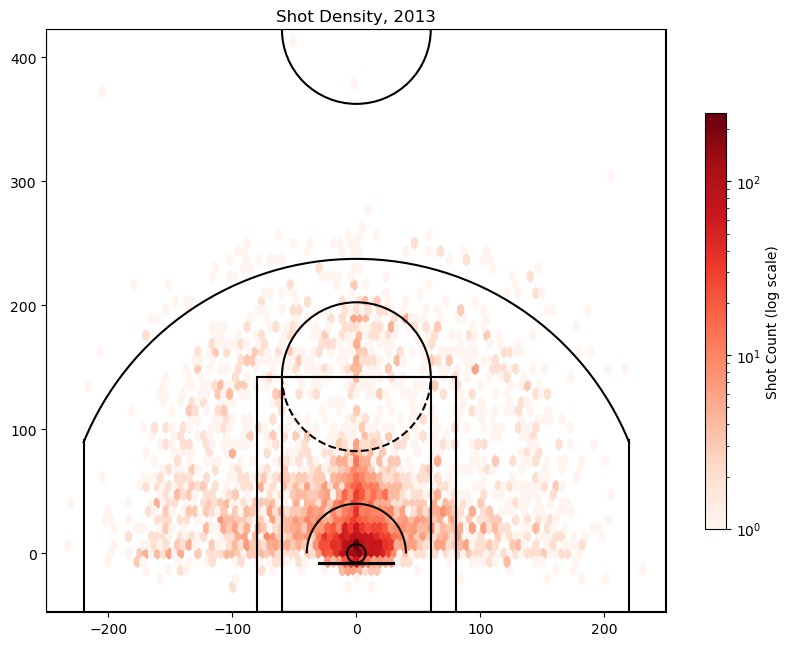

In [22]:
year2013 = finaldata[finaldata['YEAR'] == '2013']

fig, ax = plt.subplots(figsize=(10, 9))

ax.hexbin(year2013.LOC_X, year2013.LOC_Y, gridsize=100, cmap='Reds', norm=LogNorm(), zorder=1)
draw_court(ax=ax, color='black', lw=1.5)

ax.set_title("Shot Density, 2013")
ax.set_facecolor('white')
fig.colorbar(ax.collections[0], ax=ax, label='Shot Count (log scale)', shrink = 0.6)
plt.show()

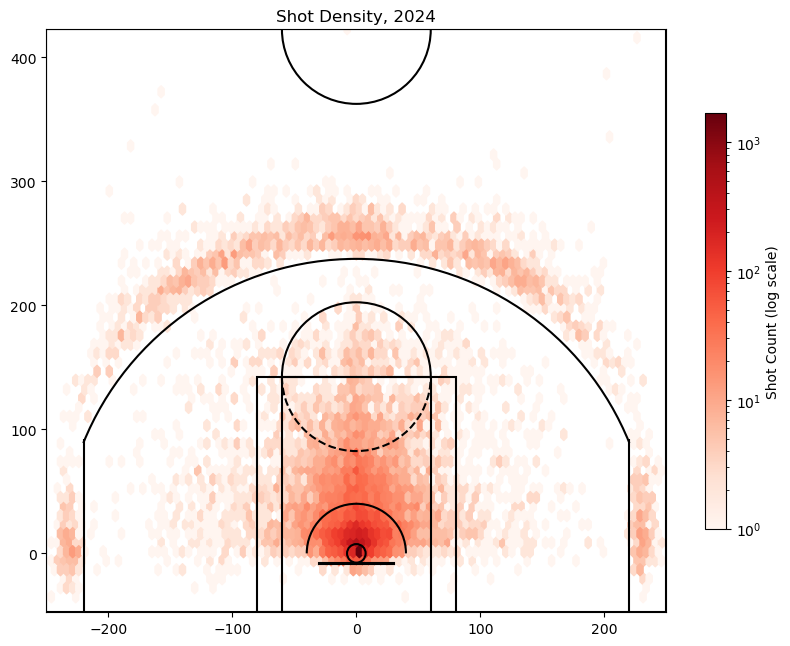

In [25]:
year2024 = finaldata[finaldata['YEAR'] == '2024']

fig, ax = plt.subplots(figsize=(10, 9))

ax.hexbin(year2024.LOC_X, year2024.LOC_Y, gridsize=100, cmap='Reds', norm=LogNorm(), zorder=1)
draw_court(ax=ax, color='black', lw=1.5)

ax.set_title("Shot Density, 2024")
ax.set_facecolor('white')
fig.colorbar(ax.collections[0], ax=ax, label='Shot Count (log scale)', shrink = 0.6)
plt.show()

We can see a clear difference in the number of three pointers taken by centers in 2024 compared to 2013. To test this statistically, we used a chi-square test to test whether the proportion of three point attempts are independent regardless of year.

In [26]:
from scipy.stats import chi2_contingency

# Filter to just 2013 and 2024
data_2013 = finaldata[finaldata['YEAR'] == '2013']
data_2024 = finaldata[finaldata['YEAR'] == '2024']

# Count 3-pointers vs non-3-pointers for each year
threes_2013 = len(data_2013[data_2013['SHOT_TYPE'] == '3PT Field Goal'])
other_2013 = len(data_2013[data_2013['SHOT_TYPE'] != '3PT Field Goal'])

threes_2024 = len(data_2024[data_2024['SHOT_TYPE'] == '3PT Field Goal'])
other_2024 = len(data_2024[data_2024['SHOT_TYPE'] != '3PT Field Goal'])

# Build the 2x2 contingency table
#              3PT    Non-3PT
# 2013       [  ,       ]
# 2024       [  ,       ]
table = [[threes_2013, other_2013],
         [threes_2024, other_2024]]

chi2, p_value, dof, expected = chi2_contingency(table)

print(f"3PT rate 2013: {threes_2013 / (threes_2013 + other_2013):.3%}")
print(f"3PT rate 2024: {threes_2024 / (threes_2024 + other_2024):.3%}")
print(f"Chi-square: {chi2:.2f}")
print(f"P-value: {p_value:.2e}")

3PT rate 2013: 1.359%
3PT rate 2024: 13.895%
Chi-square: 768.06
P-value: 4.76e-169


From this test, we can clearly see a significant difference in the number of three point shots taken in 2013 and 2024.

We will now run this test for every team in the league. 

In [36]:

results = []

for team in finaldata['TEAM_NAME'].unique():
    team_data = finaldata[finaldata['TEAM_NAME'] == team]
    
    data_2013 = team_data[team_data['YEAR'] == '2013']
    data_2024 = team_data[team_data['YEAR'] == '2024']
    
    threes_2013 = len(data_2013[data_2013['SHOT_TYPE'] == '3PT Field Goal'])
    other_2013 = len(data_2013[data_2013['SHOT_TYPE'] != '3PT Field Goal'])
    threes_2024 = len(data_2024[data_2024['SHOT_TYPE'] == '3PT Field Goal'])
    other_2024 = len(data_2024[data_2024['SHOT_TYPE'] != '3PT Field Goal'])
    
    total_2013 = threes_2013 + other_2013
    total_2024 = threes_2024 + other_2024
    
    # Skip teams with no data in either year
    if total_2013 == 0 or total_2024 == 0:
        continue
    
    # Skip if neither year has any 3-pointers
    if threes_2013 == 0 and threes_2024 == 0:
        continue
    
    # If one year has zero 3s, keep the row but skip the test
    if threes_2013 == 0 or threes_2024 == 0:
        results.append({
        'TEAM_NAME': team,
        '3PT_RATE_2013': threes_2013 / total_2013,
        '3PT_RATE_2024': threes_2024 / total_2024,
        'CHANGE': (threes_2024 / total_2024) - (threes_2013 / total_2013),
        'CHI2': chi2,
        'P_VALUE': p_value
    })

results_df = pd.DataFrame(results).sort_values('CHANGE', ascending=False)
results_df

,TEAM_NAME,3PT_RATE_2013,3PT_RATE_2024,CHANGE,CHI2,P_VALUE
11,Golden State Warriors,0.000000,0.666667,0.666667,0.259258,0.610631
7,Oklahoma City Thunder,0.000000,0.250000,0.250000,0.259258,0.610631
13,Miami Heat,0.000000,0.241379,0.241379,0.259258,0.610631
12,Chicago Bulls,0.000000,0.228876,0.228876,0.259258,0.610631
1,Philadelphia 76ers,0.000000,0.212766,0.212766,0.259258,0.610631
10,Portland Trail Blazers,0.000000,0.181273,0.181273,0.259258,0.610631
8,Utah Jazz,0.000000,0.158833,0.158833,0.259258,0.610631
9,Phoenix Suns,0.000000,0.158763,0.158763,0.259258,0.610631
3,Houston Rockets,0.000000,0.100471,0.100471,0.259258,0.610631
5,New Orleans Pelicans,0.000000,0.092188,0.092188,0.259258,0.610631


In [38]:
print(results_df.to_string())


                 TEAM_NAME  3PT_RATE_2013  3PT_RATE_2024    CHANGE      CHI2   P_VALUE
11   Golden State Warriors       0.000000       0.666667  0.666667  0.259258  0.610631
7    Oklahoma City Thunder       0.000000       0.250000  0.250000  0.259258  0.610631
13              Miami Heat       0.000000       0.241379  0.241379  0.259258  0.610631
12           Chicago Bulls       0.000000       0.228876  0.228876  0.259258  0.610631
1       Philadelphia 76ers       0.000000       0.212766  0.212766  0.259258  0.610631
10  Portland Trail Blazers       0.000000       0.181273  0.181273  0.259258  0.610631
8                Utah Jazz       0.000000       0.158833  0.158833  0.259258  0.610631
9             Phoenix Suns       0.000000       0.158763  0.158763  0.259258  0.610631
3          Houston Rockets       0.000000       0.100471  0.100471  0.259258  0.610631
5     New Orleans Pelicans       0.000000       0.092188  0.092188  0.259258  0.610631
0      Cleveland Cavaliers       0.000000  